<h1 style="color: #336699;"><b>ELIXIR Spatial course</b></h1>

<h2 style="color: #336699;">Practical 6: Multi-slice spatial data integration</h2>

<h4>8th October 2026</h4>
<h4>Benedetta Manzato, Emma Vonk (Leiden University Medical Center)</h4>

<div style="border: 2px solid #336699; padding: 15px; border-radius: 8px;">
  <span style="color: #336699; font-size: 24px; font-weight: bold;">Agenda:</span>
  <ol style="margin-top: 10px; padding-left: 25px; font-size: 17px; color: #333333;">
    <li>Uni-modal slides alignment with CAST</li>
    <li>Uni-modal slides alignment with MOSCOT</li>
    <li>Uni-modal slides alignment with COAST</li>
    <li>Multi-modal slides alignment with COAST</li>
  </ol>
</div>



In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, re
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import random
import numpy as np
import anndata as ad
from scipy.sparse import csc_matrix

from PIL import Image

import CAST


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/exports/archive/hg-funcgenom-research/bmanzato/conda_envs/cast_demo_pr6_gpu/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/exports/archive/hg-funcgenom-research/bmanzato/conda_envs/cast_demo_pr6_gpu/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/exports/archive/hg-funcgenom-research/bmanzato/conda_envs/cast_demo_pr6_gpu/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_i

In [7]:
import CAST

<font size="3"> We create an output folder in your local space to save outputs:

In [8]:
outdir = './outputs/'
if not os.path.exists(outdir):
        os.makedirs(outdir)

#### Uni-modal dataset: 10X Visium Mouse Brain Coronal

<font size="3"> You can download the sections here: [section 1](https://www.10xgenomics.com/datasets/mouse-brain-coronal-section-1-ffpe-2-standard) and [section 2](https://www.10xgenomics.com/datasets/mouse-brain-coronal-section-2-ffpe-2-standard).

### Read data 


In [9]:
# Set up paths

base_dir = "/exports/humgen/bmanzato/COAST_tutorial_data_ant"

coord_files = [
    f"{base_dir}/coord/V1_Mouse_Brain_Sagittal_Anterior_Section_1.csv",
    f"{base_dir}/coord/V1_Mouse_Brain_Sagittal_Anterior_Section_2.csv"
]
image_files = [
    f"{base_dir}/img/V1_Mouse_Brain_Sagittal_Anterior_Section_1.tif",
    f"{base_dir}/img/V1_Mouse_Brain_Sagittal_Anterior_Section_2.tif"
]
moldata_files = [
    f"{base_dir}/mol_data/section1_h5_xy.h5ad",
    f"{base_dir}/mol_data/section2_h5_xy.h5ad"
]

<font size="3"> Inspect your images:

KeyboardInterrupt: 

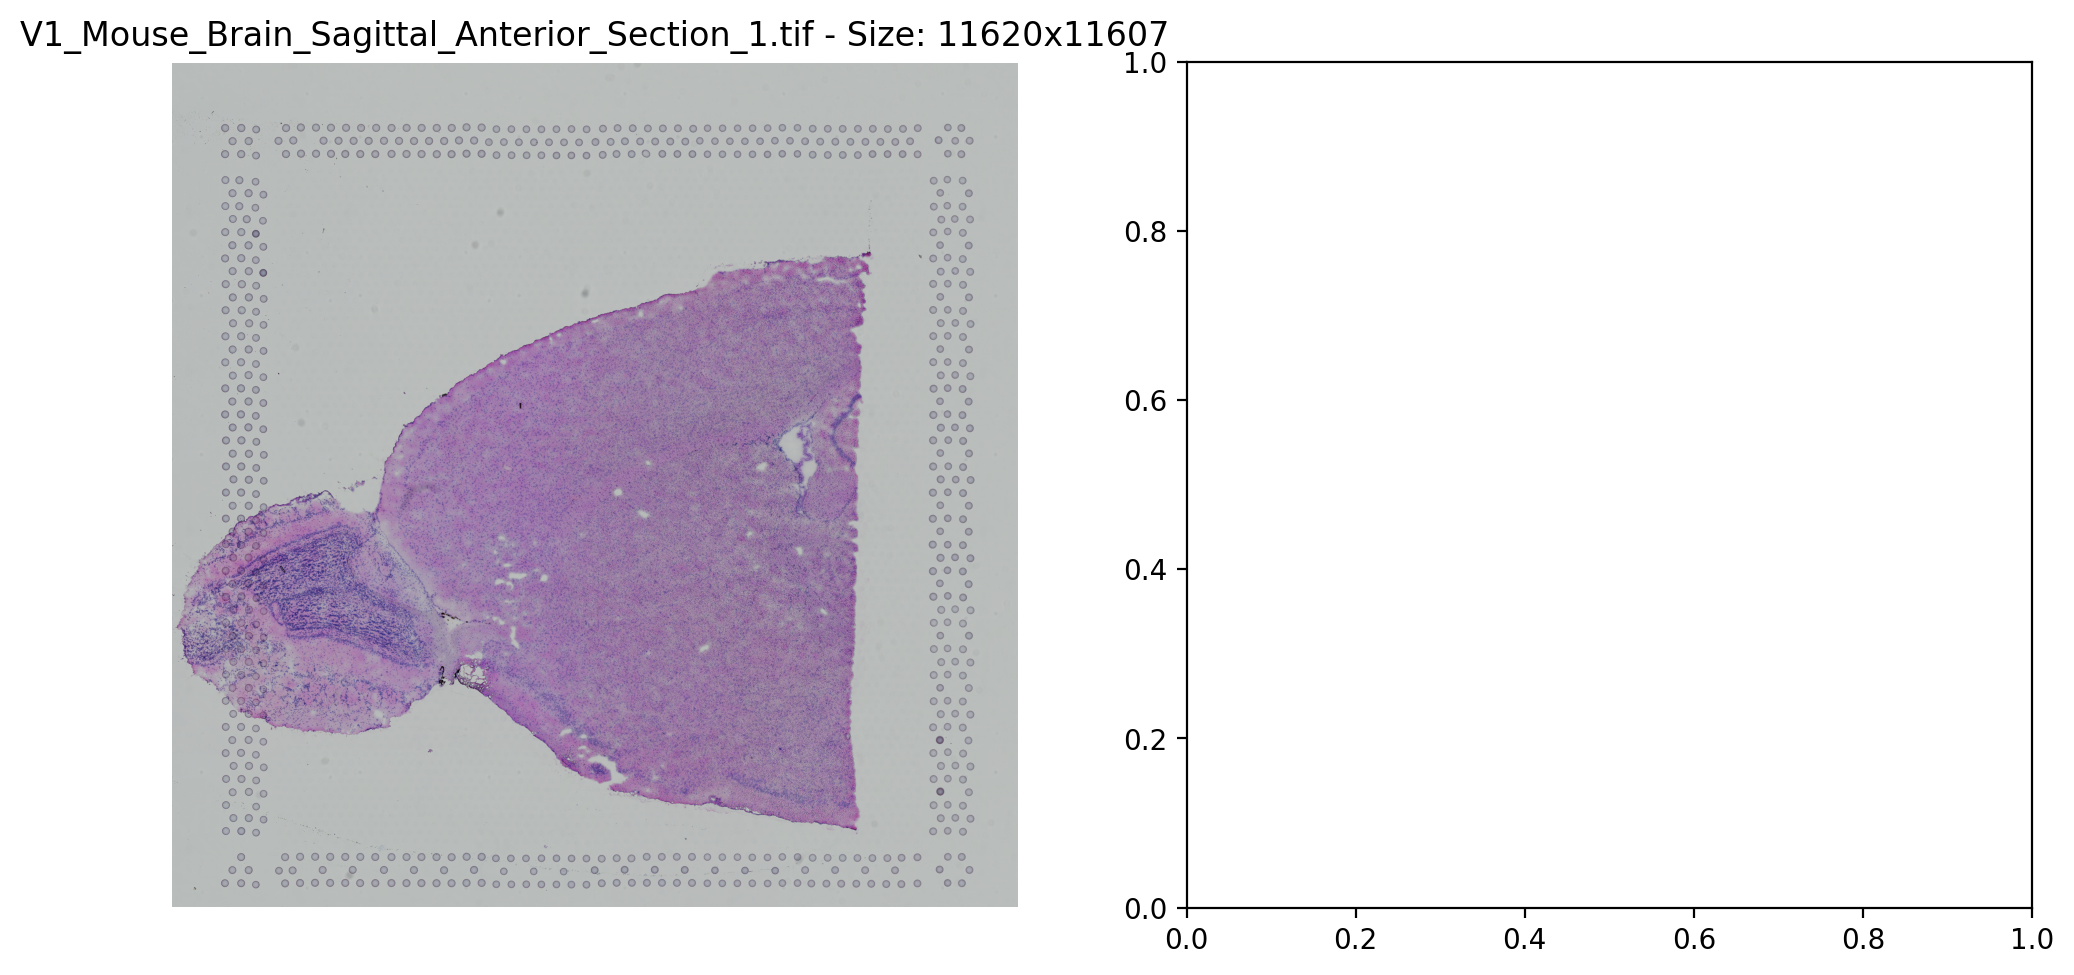

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for ax, img_path in zip(axes, image_files):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"{os.path.basename(img_path)} - Size: {img.size[0]}x{img.size[1]}", fontsize=12) 

plt.tight_layout()
plt.show()

<font size="3"> Make sure that the coordinate file and the images are in the same coordinate framework: plot images with coordinates overlaid

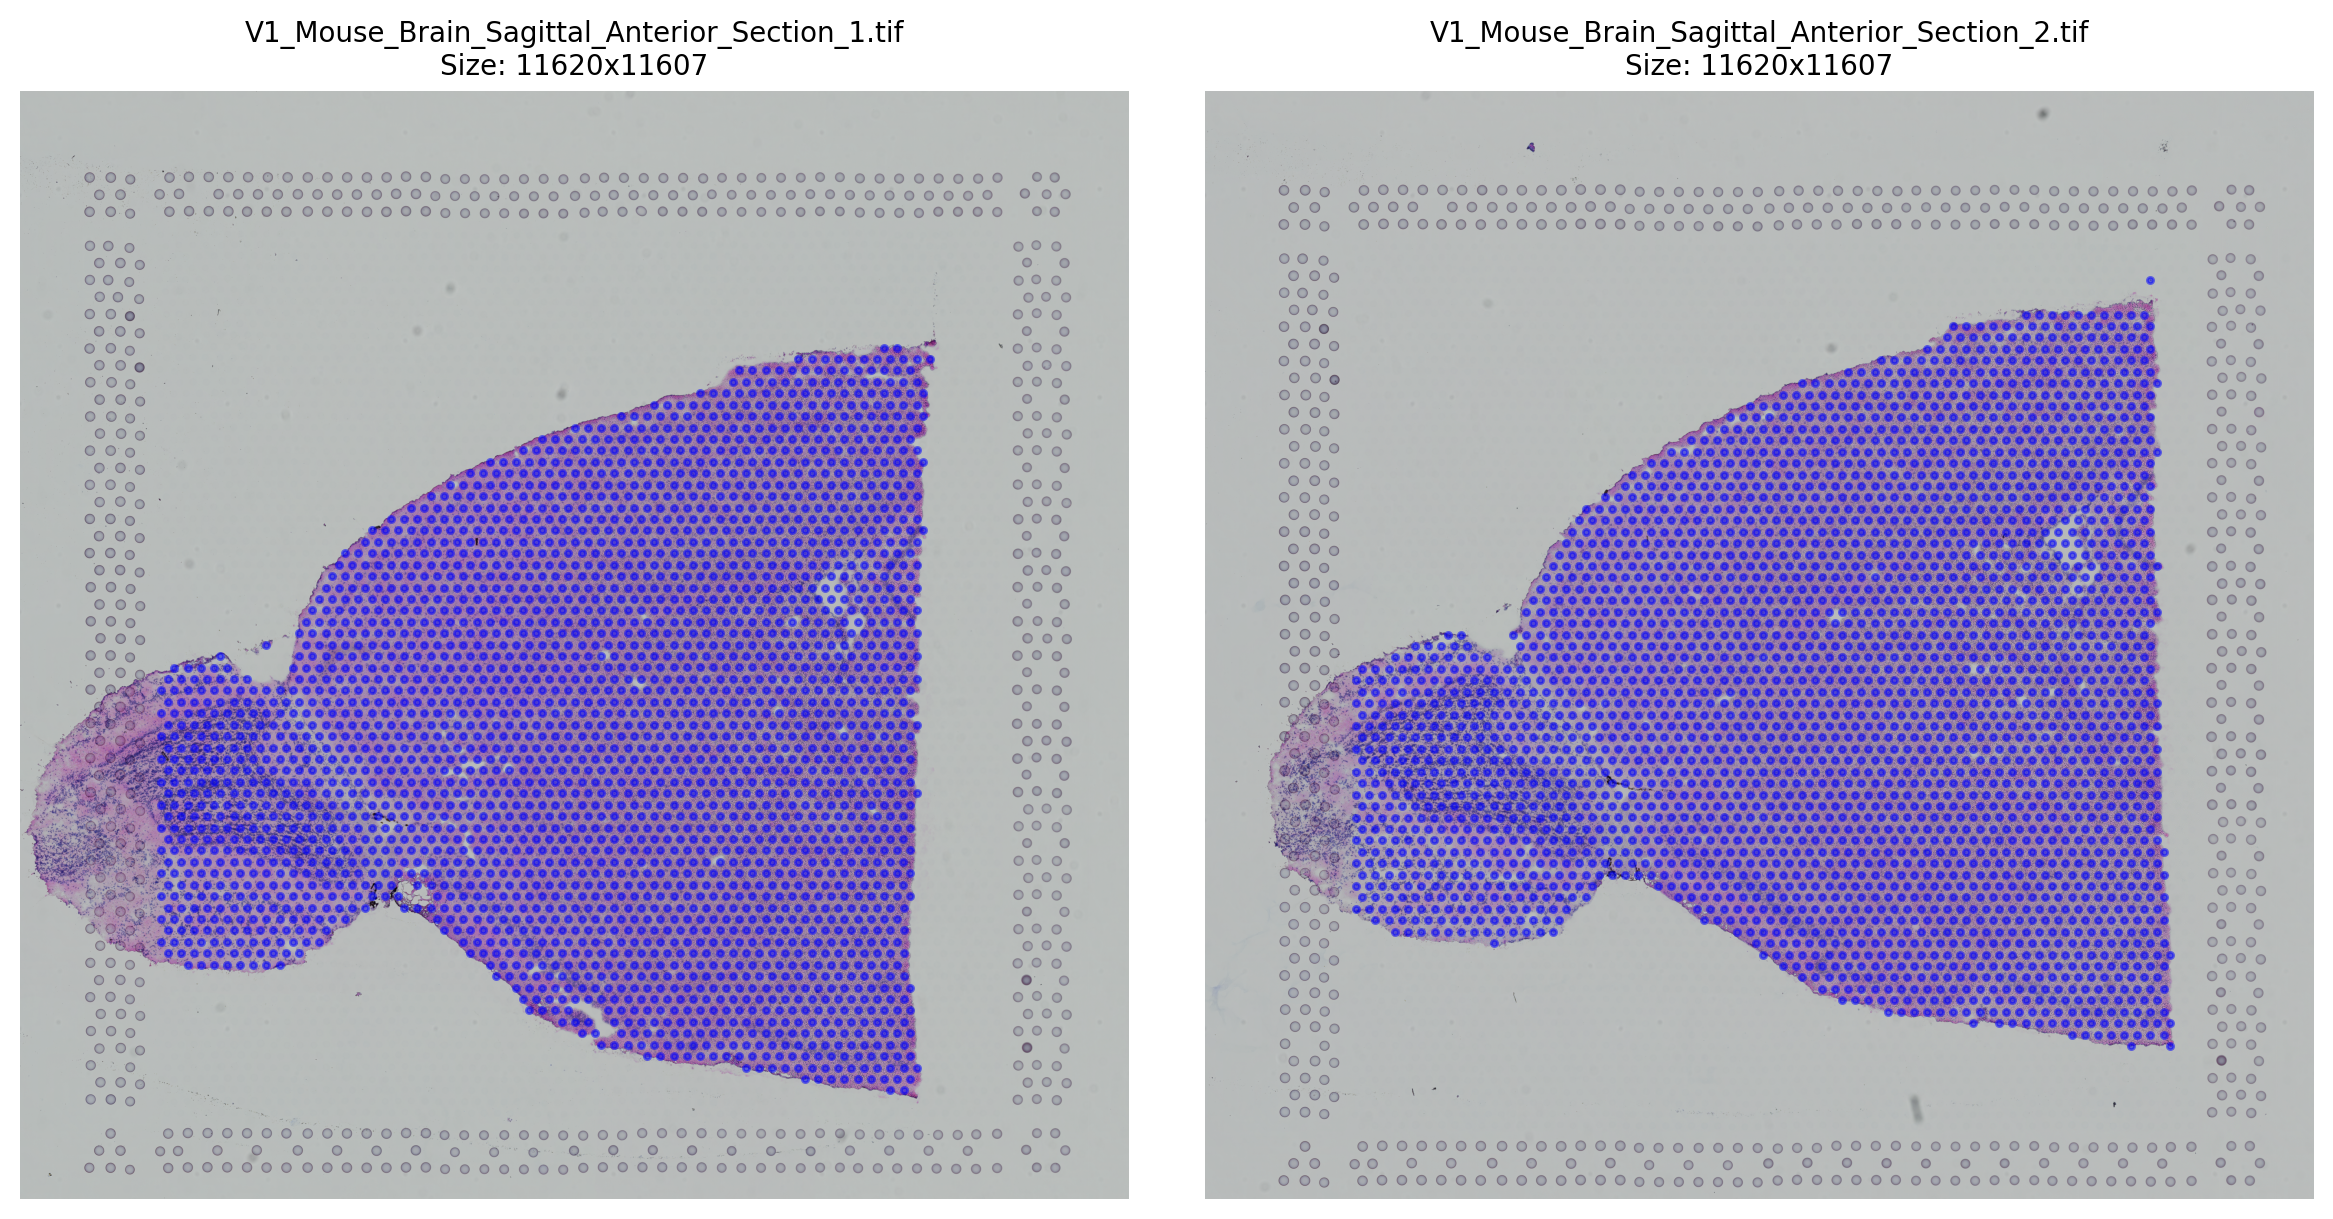

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for ax, img_path, coord_path in zip(axes, image_files, coord_files):
    # Load image
    img = Image.open(img_path)

    # Load coordinates (support csv, h5ad, h5)
    if coord_path.endswith(".csv"):
        df = pd.read_csv(coord_path, index_col=0)
    elif coord_path.endswith(".h5ad"):
        adata = sc.read_h5ad(coord_path)
        df = adata.obs[['x', 'y']].copy()
    elif coord_path.endswith(".h5"):
        adata = sc.read_10x_h5(coord_path)
        df = adata.obs[['x', 'y']].copy()
    else:
        raise ValueError(f"Unsupported coordinate file: {coord_path}")

    # Plot image
    ax.imshow(img)

    # Overlay points
    if 'x' in df.columns and 'y' in df.columns:
        ax.scatter(df['x'], df['y'], s=5, c='blue', alpha=0.5)

    ax.axis('off')
    ax.set_title(f"{os.path.basename(img_path)}\nSize: {img.size[0]}x{img.size[1]}", fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
import gc
# collect garbage
gc.collect()

360

## 1. Uni-modal alignment using CAST
[Search and match across spatial omics samples at single-cell resolution (Tang et al. 2024)](https://www.nature.com/articles/s41592-024-02410-7)

In [12]:
#import CAST

<figure>
    <img src="https://raw.githubusercontent.com/wanglab-broad/CAST/main/README_CAST_diagram.png" width="700" height="280" alt="CAST diagram illustrating the workflow">
    <figcaption>From <a href="https://www.nature.com/articles/s41592-024-02410-7" target="_blank">Tang et al. (2024)</a></figcaption>
</figure>

<font size="3">
Load Data
    
- CAST Mark method only require the following data modalities:
    1. gene expression raw counts
    2. spatial coordinates of the cells

- We organize spatial omics data in the AnnData format:
    - `adata.X` stores the gene expression raw counts
    - `adata.obs` contains important cell-level annotation, including spatial coordinates (column name: `'x'`, `'y'`)
    - Data for different experimental samples are combined in a single Anndata object (column name `'sample'`)

<font size="3"> Settings

In [13]:
# Load data
adata1 = ad.read_h5ad(f'{base_dir}/mol_data/section1_data.h5ad')
adata2 = ad.read_h5ad(f'{base_dir}/mol_data/section2_data.h5ad')

adata1.obs['sample'] = 'section1'
adata2.obs['sample'] = 'section2'

# Define a cleanup function to fix .var duplicates
def prepare_adata(adata, name):
    if adata.var.index.duplicated().any():
        print(f"Found duplicate gene names in {name}. Fixing now...")
        adata.var_names_make_unique() # This appends '-1', '-2' etc. to duplicate gene names
    return adata

# Apply to both
adata1 = prepare_adata(adata1, 'section1')
adata2 = prepare_adata(adata2, 'section2')

# 3. Concatenate using index_unique to handle .obs collision
adata = ad.concat(
    [adata1, adata2], 
    keys=['sec1', 'sec2'], 
    index_unique='_'
)

Found duplicate gene names in section1. Fixing now...
Found duplicate gene names in section2. Fixing now...


In [14]:
adata.obs

,in_tissue,array_row,array_col,y,x,sample
AAACAAGTATCTCCCA-1_sec1,1,50,102,7474,8500,section1
AAACACCAATAACTGC-1_sec1,1,59,19,8552,2788,section1
AAACAGAGCGACTCCT-1_sec1,1,14,94,3163,7950,section1
AAACAGCTTTCAGAAG-1_sec1,1,43,9,6636,2100,section1
AAACAGGGTCTATATT-1_sec1,1,47,13,7115,2375,section1
...,...,...,...,...,...,...
TTGTTAGCAAATTCGA-1_sec2,1,22,42,4255,4469,section2
TTGTTCAGTGTGCTAC-1_sec2,1,24,64,4495,5983,section2
TTGTTGTGTGTCAAGA-1_sec2,1,31,77,5333,6878,section2
TTGTTTCATTAGTCTA-1_sec2,1,60,30,8806,3643,section2


In [15]:
adata.layers['norm_1e4'] = sc.pp.normalize_total(adata, target_sum=1e4, inplace=False)['X'].toarray() # we use normalized counts for each cell as input gene expression

samples = np.unique(adata.obs['sample']) # used samples in adatas
coords_raw = {sample_t: np.array(adata.obs[['x','y']])[adata.obs['sample'] == sample_t] for sample_t in samples}
exp_dict = {sample_t: adata[adata.obs['sample'] == sample_t].layers['norm_1e4'] for sample_t in samples}

<font size="3"> Run

In [16]:
outdir = './CAST_outputs/'
if not os.path.exists(outdir):
        os.makedirs(outdir)

from CAST.CAST_Mark import train_seq, delaunay_dgl

### Run the model to generate the graph embedding
#embed_dict = CAST.CAST_MARK(coords_raw,exp_dict,outdir)

### CPU with single core may takes long time for each epoch. If it takes too long, you could set:
embed_dict = CAST_Mark(coords_raw,exp_dict,outdir,epoch_t = 10)#<font size="3"> In this case the feature metadata are stored in a separate csv. We need to read read and then add them to the right field in the AnnData object

NameError: name 'CAST_Mark' is not defined

In [ ]:
CAST.kmeans_plot_multiple(embed_dict, samples, coords_raw, 'coronal', outdir, k=15, dot_size=20, minibatch=False)

<font size="3"> To align the slices with preserving the cell organization, `CAST_STACK()` is used to perform gradient-descent-based rigid registration and free-form deformation (FFD) to get a proper transformation.  

<font size="3"> Here are the parameters used in this function:  
- `coords_raw` - The dictionary of the coordinates matrix with sample name.  
- `embed_dict` - The dictionary of the graph embedding generated by CAST Mark with sample name.   
- `output_path` - The output folder path.  
- `graph_list` - The list of [`query sample`, `reference sample`]. The query sample will be aligned to the reference sample.  
- `params_dist` - The parameter dictionary for the CAST Stack.  
    - `dataname` - The dataset name.
    - `gpu` - The index of the gpu if the GPU device is available.  
    
    **Affine parameters**  
    
    - `iterations` - Iterations of the affine transformation.  
    - `alpha_basis` - The coefficient for updating the affine transformation parameter.
    - `dist_penalty1` - Distance penalty parameter in affine transformation. When the distance of the query cell to the nearest neighbor in reference sample is greater than a distance threshold (by default, average cell distance), CAST Stack will add additional distance penalty. The initial cost function value of these cells will be multiplied by the `dist_penalty1`. The value `0` indicates no additional distance penalty.
    - `bleeding` - When the reference sample is larger than the query sample, for efficient computation, only the region of the query sample with bleeding distance will be considered when calculating the cost function.  
    - `d_list` - CAST Stack will perform pre-location to find an initial alignment. The value in the `d_list` will be multiplied by the query sample to calculate the cost function. For example, 2 indicates the two-fold increase of the coordinates.
    - `attention_params` - The attention mechanism to increase the penalty of the cells. It is invalid when the `dist_penalty` = 0.  
        - `1st - attention_region` - The True/False index of all the cells of the query sample or None.
        - `2nd - double_penalty` - The `average cell distance / double_penalty` will be used in distance penalty for the cells with attention.  
        - `3rd - penalty_inc_all` - The additional penalty for the attention cells. The initial cost function value of these cells will be multiplied by `penalty_inc_all`.  
        - `4th - penalty_inc_both` - The additional penalty for the cells with distance penalty and attention. The initial cost function value of these cells will be multiplied by `(penalty_inc_both/dist_penalty + 1)`.  
        
    **FFD parameters**  
    
    - `dist_penalty2` - Distance penalty parameter in FFD. Refer to `dist_penalty1`.  
    - `alpha_basis_bs` - The coefficient for updating the FFD parameter.  
    - `meshsize` - mesh size for the FFD.  
    - `iterations_bs` - Iterations of the FFD.  
    - `attention_params_bs` - The attention mechanism to increase the penalty of the cells. Refer to `attention_params`.  
    - `mesh_weight` - The weight matrix for the mesh grid. The same size of the mesh or None.  

In [ ]:
import torch

query_sample = 'section2'

params_dist = CAST.reg_params(dataname = query_sample,
                            #gpu = 0 if torch.cuda.is_available() else -1, 
                            diff_step = 5,
                            #### Affine parameters
                            iterations=500,
                            dist_penalty1=0,
                            bleeding=500,
                            d_list = [3,2,1,1/2,1/3],
                            attention_params = [None,3,1,0], 
                            #### FFD parameters    
                            dist_penalty2 = [0],
                            alpha_basis_bs = [500],
                            meshsize = [8],
                            iterations_bs = [400],
                            attention_params_bs = [[None,3,1,0]],
                            mesh_weight = [None])
params_dist.alpha_basis = torch.Tensor([1/1000,1/1000,1/50,5,5]).reshape(5,1).to(params_dist.device)
coords_final = CAST.CAST_STACK(coords_raw,embed_dict,outdir,samples,params_dist)

In [ ]:
coords_final

In [ ]:
# collect garbage
gc.collect()

<font size="3"> Visualize the aligned coordinates:

In [ ]:
plt.figure(figsize=(8, 6), dpi=300)

plt.scatter(coords_final['x'], adata.obs['y'], color='#87c38f', label='section1', s=1, alpha=0.6)
plt.scatter(coords_final['x'], e2s7_subset.obs['y'], color='#b388eb', label='section2', s=1, alpha=0.6)

plt.xlabel('x')
plt.ylabel('y')
plt.title(' ')
plt.legend()

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

## 3. Uni-modal alignment using COAST
[Image-guided alignment of consecutive multi-modal tissue slides (Manzato et al. 2025)](https://www.biorxiv.org/content/10.64898/2025.12.02.690676v1.article-metrics)

<figure>
    <img src="https://raw.githubusercontent.com/mahfouzlab/COAST/main/workflow.png" width="800" height="400" alt="COAST conceptual workflow diagram">
    <figcaption>From <a href="https://www.biorxiv.org/content/10.64898/2025.12.02.690676v1" target="_blank">Manzato et al. (2025)</a></figcaption>
</figure>

<font size="3"> COAST makes use of the stained images associated with the molecular data. Make sure that the coordinate file and the images are in the same coordinate framework: plot images with coordinates overlaid

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for ax, img_path, coord_path in zip(axes, image_files, coord_files):
    # Load image
    img = Image.open(img_path)

    # Load coordinates (support csv, h5ad, h5)
    if coord_path.endswith(".csv"):
        df = pd.read_csv(coord_path, index_col=0)
    elif coord_path.endswith(".h5ad"):
        adata = sc.read_h5ad(coord_path)
        df = adata.obs[['x', 'y']].copy()
    elif coord_path.endswith(".h5"):
        adata = sc.read_10x_h5(coord_path)
        df = adata.obs[['x', 'y']].copy()
    else:
        raise ValueError(f"Unsupported coordinate file: {coord_path}")

    # Plot image
    ax.imshow(img)

    # Overlay points
    if 'x' in df.columns and 'y' in df.columns:
        ax.scatter(df['x'], df['y'], s=5, c='blue', alpha=0.5)

    ax.axis('off')
    ax.set_title(f"{os.path.basename(img_path)}\nSize: {img.size[0]}x{img.size[1]}", fontsize=10)

plt.tight_layout()
plt.show()

#### Module 1: extract image features from high-resolution image
<font size="3"> Using a pretrained Vision Transformer, <code>extract_features</code> extracts and saves features for each file in each of the two images, separately.

<p style="font-size:16px; margin-top:8px;">
<strong> <code>extract_features</code> function arguments</strong>
</p>
<ul style="font-size:14px; margin-top:4px;">
  <li><strong>coord_path (str, required)</strong><br>
    • Path to the CSV file containing spot coordinates.<br>
    • Required columns: <code>x</code> and <code>y</code> (integer pixel coordinates).<br>
    • Index should be spot IDs (e.g., Visium barcodes).<br>
    • Spots must correspond to positions in the tissue image.
  </li>

  <li style="margin-top:14px;"><strong>img_path (str, required)</strong><br>
    • Path to the high-resolution tissue image.<br>
    • Supported formats: JPEG, PNG, TIFF.<br>
    • Spots in the coord file should correspond to positions in this image.
  </li>

  <li style="margin-top:14px;"><strong>output_name (str, required)</strong><br>
    • Prefix for the output CSV files.<br>
  </li>

  <li style="margin-top:14px;"><strong>outdir (str, required)</strong><br>
    • Directory where the ViT features folder and output CSVs will be saved.
  </li>

  <li style="margin-top:14px;"><strong>patch_size (int, default=224)</strong><br>
    • Width and height of each square patch (in pixels) extracted from the image.
  </li>

  <li style="margin-top:14px;"><strong>step_size (int, default=224)</strong><br>
    • Step size for grid-based patch extraction (in pixels).<br>
    • Determines the spacing between grid patches.
  </li>

  <li style="margin-top:14px;"><strong>pad (str, default='none')</strong><br>
    • Options: <code>none</code>, <code>left</code>, <code>right</code>, <code>top</code>, <code>bottom</code>.<br>
    • Adds padding to the image before patch extraction to further guide the alignment.
  </li>

  <li style="margin-top:14px;"><strong>mode (str, default='moldata')</strong><br>
    • Options: <code>moldata</code> (tissue-guided + grid patches) or <code>nomoldata</code> (grid patches only).
  </li>
</ul>


In [ ]:
# set output name as the name of the image files
tissues = [os.path.splitext(os.path.basename(f))[0] for f in image_files]

tissues

In [ ]:
from COAST.extract_features import extract_features

results = {}
for section, output_name in zip(tissues, tissues):
    coord_file = f"{base_dir}/coord/{section}.csv"
    img_file = f"{base_dir}/img/{section}.tif"
    
    features, coords = extract_features(
        coord_path=coord_file,
        img_path=img_file,
        output_name=output_name,
        outdir=outdir,
        patch_size=224,
        step_size=224,
        pad="none",
        mode="moldata"
    )

    results[output_name] = {"features": features, "coords": coords}
    print(f"[INFO] Finished extracting features for {section}")
    print('\n\n')

<font size="3"> <p style="font-size:15px; margin-top:0;"> Visualize the in-tissue and grid patches 

In [ ]:
image_dir = f"{base_dir}/img"
vit_dir = f"{outdir}/ViT_features/"

image_files = sorted([
    os.path.join(image_dir, f) for f in os.listdir(image_dir)
    if f.lower().endswith(('.tif', '.tiff', '.png', '.jpg'))
])

vit_coord_files = sorted([
    os.path.join(vit_dir, f) for f in os.listdir(vit_dir)
    if f.lower().endswith('_vit_coord.csv')
])

fig, axes = plt.subplots(1, len(image_files), figsize=(6*len(image_files), 6), dpi=200)

for ax, img_path, coord_path in zip(axes, image_files, vit_coord_files):
    # Load image
    img = Image.open(img_path)
    
    # Load coordinates
    df = pd.read_csv(coord_path, index_col=0)
    
    # Determine dot colors
    colors = ['blue' if str(idx).endswith('_intissue') else 'red' for idx in df.index]
    
    # Plot
    ax.imshow(img)
    ax.scatter(df['x'], df['y'], s=3, c=colors, alpha=0.6)
    ax.axis('off')
    ax.set_title(os.path.basename(img_path), fontsize=14)

plt.tight_layout()
plt.show()

<font size="3"> <p style="font-size:15px; margin-top:8px;">
Here we can visualize tissue sections using features extracted from high-resolution images. <code>run_umap_clustering</code> performs three main tasks:
</p>
<ul style="font-size:15px; margin-top:4px;">
  <li><strong>UMAP clustering:</strong> Combines features from all tissue sections, reduces their dimensionality with UMAP, and groups similar tiles into clusters. Clusters are shown both by color and by tissue section.</li>
  <li style="margin-top:15px;"><strong>Spatial plots:</strong> Shows the location of each tile on the original tissue image, colored by cluster, so you can see how similar regions are distributed spatially.</li>
</ul>

<p style="font-size:15px; margin-top:4px;">
When <code>background=True</code>, the plot includes both tissue-guided and grid patches; when <code>background=False</code>, only the molecular-data spots are shown.
</p>

In [ ]:
from COAST.coast_visualization import run_umap_clustering

df_all = run_umap_clustering(outdir, n_clusters=9, spot_size=12, background=False)

<font size="3"> <p style="font-size:15px; margin-top:0;"> Now we will use the morphology image embeddings to map the query spots to the reference coordinate space

#### Module 2: Alignment with CAST

<p style="font-size:15px; margin-top:8px;">
<strong> <code>run_cast</code> function arguments</strong>
</p>
<ul style="font-size:15px; margin-top:4px;">
  <li><strong>outdir (str, required)</strong><br>
    • Base output directory for COAST / ViT features.<br>
    • Expects a subfolder <code>ViT_features/</code> containing <code>*_vit_mf.csv</code> and <code>*_vit_coord.csv</code> files for each tissue.<br>
    • Will create a <code>CAST_output/</code> subfolder to store aligned coordinates.
  </li>
</ul>

<p style="font-size:15px; margin-top:8px;">
<li style="margin-top:15px;"><strong>Outputs</strong><br>
    • <code>CAST_output/*_aligned.csv</code>: Aligned coordinates for each tissue, indexed by original patch IDs.<br>
    • Tensors used in alignment saved as <code>.pt</code> files for reproducibility.
  </li>
  </li>
</ul>


In [ ]:
from COAST.CAST_alignment import run_cast

run_cast(outdir)

<p style="font-size:15px; margin-top:8px;">
After aligning multiple tissue sections with CAST, <code>plot_final_aligned_scatter</code> shows all sections together in the common coordinate space.</p>

<p style="font-size:15px; margin-top:4px;">
When <code>background=True</code>, the plot includes both tissue-guided and grid patches; when <code>background=False</code>, only the molecular-data spots are shown.
</p>

In [ ]:
from COAST.coast_visualization import plot_final_aligned_scatter

plot_final_aligned_scatter(outdir, spot_size=25, background=False)

#### Module 3: kNN spot matching

<p style="font-size:15px; margin-top:8px;">
This module builds a combined dataset from two tissue sections. Spots are matched using a KD-tree based on the closest Euclidean distance, with a <strong>maximum distance threshold</strong> that should be chosen according to the step size between molecular spots.
</p>

<ul style="font-size:15px; margin-top:4px;">
  <li style="margin-top:8px;"><strong>match_spots:</strong> Matches spots between tissues using KD-tree based on the closest Euclidean distance and uses a distance threshold (<code>max_distance</code> that should be chosen according to the step size between molecular spots.</li>
  <li style="margin-top:8px;"><strong>build_multimodal_anndata:</strong> Combines matched features into a single AnnData object. If metadata is provided, it is concatenated in <code>.obs</code>.</li>
</ul>

<p style="font-size:15px; margin-top:8px;">
The final AnnData is saved to <code>outdir/multimodal_anndata/multimodal_dataset.h5ad</code>.
</p>


In [ ]:
from COAST.spot_matching import match_spots, build_multimodal_anndata

max_distance = 64

# Returns DataFrame with aligned indices
ccf_matches = match_spots(outdir, max_distance=max_distance)
ccf_matches.head()

In [ ]:
mol_dir = "/exports/humgen/bmanzato/COAST_git/mol_data"
coord_dir = "/exports/humgen/bmanzato/COAST_git/coord"

multimodal_anndata = build_multimodal_anndata(
    outdir=outdir,
    mol_dir=mol_dir,
    coord_dir=coord_dir,
    metadata=coord_dir,
    max_distance=max_distance
)

## 4. Multi-modal alignment using COAST
[Image-guided alignment of consecutive multi-modal tissue slides (Manzato et al. 2025)](https://www.biorxiv.org/content/10.64898/2025.12.02.690676v1.article-metrics)

#### Multi-modal dataset: Spatial Transcriptomics and Spatial Metabolomics of IRI Mouse Kidney
<font size="3"> IRI: Ischemia reperfusion injury

<font size="3"> Data availability:
<ul style="font-size:15px; margin-top:4px;">
  <li style="margin-top:8px;"><strong>Spatial Transcriptomics:</strong> GSE298899 (obtained with Stereo-seq technology)</li>
  <li style="margin-top:8px;"><strong>Spatial Metabolomics:</strong> https://zenodo.org/records/17722895 (obtained with MALDI-MSI technology).</li>
</ul>

In [ ]:
# Setup paths

base_dir = "/exports/humgen/bmanzato/valid_data/bIRI_data/iri1_data"

coord_files = [
    f"{base_dir}/coord/msi_IRI1.csv",
    f"{base_dir}/coord/ss_IRI1.h5ad"
]
image_files = [
    f"{base_dir}/img/msi_IRI1.tif",
    f"{base_dir}/img/ss_IRI1.tif",
]
moldata_files = [
    f"{base_dir}/data/msi_data.csv",
    f"{base_dir}/data/stereoseq_IRI1.h5ad"
]
outdir = "/exports/humgen/bmanzato/teaching/Uppsala/mm_output/"

<font size="3"> Visualize images

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for ax, img_path in zip(axes, image_files):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray') 
    ax.axis('off')
    ax.set_title(f"{os.path.basename(img_path)} - Size: {img.size[0]}x{img.size[1]}", fontsize=12)

plt.tight_layout()
plt.show()

<font size="3"> Again, make sure that the coordinate file and the images are in the same coordinate framework: plot images with coordinates overlaid

In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=200)

for i, (ax, img_path, coord_path) in enumerate(zip(axes, image_files, coord_files)):
    # Load image
    img = Image.open(img_path)

    # Load coordinates (support csv, h5ad, h5)
    if coord_path.endswith(".csv"):
        df = pd.read_csv(coord_path, index_col=0)
    elif coord_path.endswith(".h5ad"):
        adata = sc.read_h5ad(coord_path)
        df = adata.obs[['x', 'y']].copy()
    else:
        raise ValueError(f"Unsupported coordinate file: {coord_path}")

    # --- Get total spots before sampling ---
    total_spots = len(df)

    # --- Sample different percentages based on tissue index ---
    # i == 0 is the first tissue (10%), i == 1 is the second tissue (80%)
    fraction = 0.1 if i == 0 else 0.8

    if 'x' in df.columns and 'y' in df.columns:
        df_sampled = df.sample(frac=fraction, random_state=42)
    else:
        df_sampled = df

    # Plot image in grayscale
    ax.imshow(img, cmap='gray')

    # Overlay sampled points
    if 'x' in df_sampled.columns and 'y' in df_sampled.columns:
        ax.scatter(df_sampled['x'], df_sampled['y'], s=0.1, c='blue', alpha=0.5)
    
    ax.axis('off')
    
    # --- Updated title showing total spots and percentage used ---
    pct_label = f"{int(fraction * 100)}%"
    title_text = f"{os.path.basename(img_path)}\nSize: {img.size[0]}x{img.size[1]} | Total: {total_spots:,} (Plotted: {pct_label})"
    ax.set_title(title_text, fontsize=10)

plt.tight_layout()
plt.show()

<font size="3"> COAST requires GPU for high-resolution datasets with many datapoints. We precomputed the results for you with the following code:

#### Module 1

```python
from COAST.extract_features import extract_features

results = {}
for section, output_name in zip(tissues, tissues):
    coord_file = f"{base_dir}/coord/{section}.csv"
    img_file = f"{base_dir}/img/{section}.tif"
    
    features, coords = extract_features(
        coord_path=coord_file,
        img_path=img_file,
        output_name=output_name,
        outdir=outdir,
        patch_size=224,
        step_size=224,
        pad="none",
        mode="moldata"
    )

    results[output_name] = {"features": features, "coords": coords}
    print(f"[INFO] Finished extracting features for {section}")
    print('\n\n')

#### Module 2

```python

from COAST.CAST_alignment import run_cast

run_cast(outdir)

#### Module 3

```python
from COAST.spot_matching import match_spots, build_multimodal_anndata

max_distance = 64

# Returns DataFrame with aligned indices
ccf_matches = match_spots(outdir, max_distance=max_distance)
ccf_matches.head()

```python
### only works if mode = 'moldata'

mol_dir = "/exports/humgen/bmanzato/COAST_git/mol_data"
coord_dir = "/exports/humgen/bmanzato/COAST_git/coord"

multimodal_anndata = build_multimodal_anndata(
    outdir=outdir,
    mol_dir=mol_dir,
    coord_dir=coord_dir,
    metadata=coord_dir,
    max_distance=max_distance
)

<font size="3"> Here you can read the precomputed aligned tissues:

In [ ]:
multimodal_anndata = sc.read_h5ad("/exports/humgen/bmanzato/COAST_package/output_iri1/multimodal_anndata/multimodal_dataset.h5ad")

In [ ]:
multimodal_anndata.obs

In [ ]:
### plot the results 

msi_aligned = pd.read_csv("/exports/humgen/bmanzato/valid_data/bIRI_data/FINAL_IRI_07082025/COAST_results/2_final_coord/bIRI1/coord_final_msi.csv",index_col=0)
ss_aligned = pd.read_csv("/exports/humgen/bmanzato/valid_data/bIRI_data/FINAL_IRI_07082025/COAST_results/2_final_coord/bIRI1/coord_final_stseq.csv",index_col=0)

#msi_aligned = msi_aligned[~msi_aligned.index.str.contains('_grid', regex=False)]
#ss_aligned = ss_aligned[~ss_aligned.index.str.contains('_grid', regex=False)]

In [ ]:
msi_aligned

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=300)

plt.scatter(msi_aligned['0'], msi_aligned['1'], color='#87c38f', label='MSI', s=0.5, alpha=0.6)
plt.scatter(ss_aligned['0'], ss_aligned['1'], color='#b388eb', label='Stereo-seq', s=0.5, alpha=0.6)

plt.xlabel('x')
plt.ylabel('y')
plt.title(' ')
plt.legend()

plt.gca().set_aspect('equal', adjustable='box')

plt.show()

In [ ]:
### explore it 